TASK_2--->DESCRIPTIVE BEHAVIOR ANALYSIS

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df=pd.read_csv(r"C:\Users\Divyani Singh\OneDrive\Desktop\Internshala DS Course\All_Courses\ML\Snapdeal_Project\Snapdeal_Cleaned.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Timestamp                                      800 non-null    str  
 1   age                                            800 non-null    int64
 2   Gender                                         800 non-null    str  
 3   Purchase_Frequency                             800 non-null    str  
 4   Purchase_Categories                            800 non-null    str  
 5   Personalized_Recommendation_Frequency          800 non-null    str  
 6   Browsing_Frequency                             800 non-null    str  
 7   Product_Search_Method                          800 non-null    str  
 8   Search_Result_Exploration                      800 non-null    str  
 9   Customer_Reviews_Importance                    800 non-null    int64
 10  Add_to_Cart_B

In [24]:
#Summary of customer Age-
print("Age Summary  Statistics:\n", df['age'].describe())

#Checking if the data entry is in chunk or a data entry-
print("Rows with age under 13:\n", df[df['age']<13][['age']])

# Checking for random noise-
print("Distribution of low ages(under 13):\n",df[df['age']<13]['age'].value_counts().sort_index())

Age Summary  Statistics:
 count    800.000000
mean      36.053750
std       19.310087
min        3.000000
25%       18.000000
50%       37.000000
75%       53.000000
max       67.000000
Name: age, dtype: float64
Rows with age under 13:
      age
6     10
8      8
9     11
12     7
21    10
..   ...
756   10
763   11
774   11
781    8
793    4

[114 rows x 1 columns]
Distribution of low ages(under 13):
 age
3     12
4     12
5      9
6     12
7     13
8     15
9     15
10    11
11    12
12     3
Name: count, dtype: int64


Note- The checking done above confirms that data is fairly evenly spread across ages 3 to 12.So, we will keep these rows instead of dropping them. 

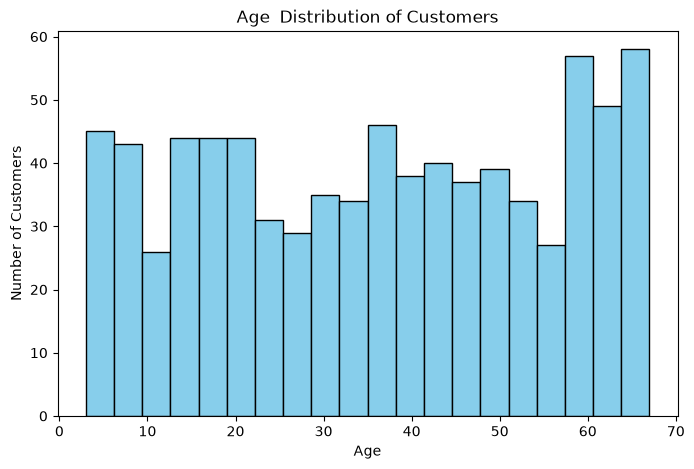

In [25]:
# Summary of Age Distribution-
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age  Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

Age data shows nearly a uniform distribution with no natural demographic clustering including implausible values(114 respondents under 13 ), which clealry indicate that this field is randomly generated for the survey dataset rather than having real customer ages.

Gender Distribution (counts):
 Gender
Male                 213
Female               201
Prefer not to say    194
Others               192
Name: count, dtype: int64

Gender Distribution (%):
 Gender
Male                 26.6
Female               25.1
Prefer not to say    24.2
Others               24.0
Name: proportion, dtype: float64


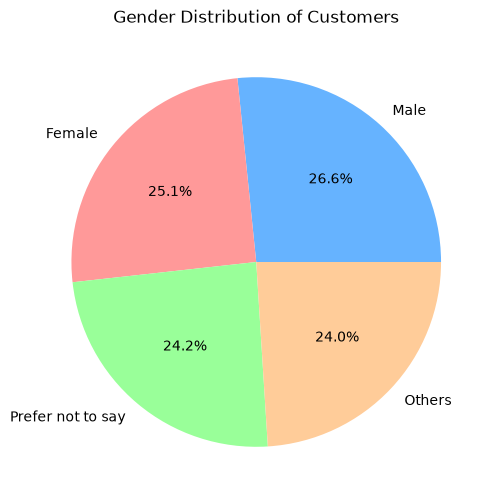

In [26]:
print("Gender Distribution (counts):\n", df['Gender'].value_counts())
print("\nGender Distribution (%):\n", df['Gender'].value_counts(normalize=True).round(3) * 100)


plt.figure(figsize=(6,6))
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999','#99ff99','#ffcc99'])
plt.title('Gender Distribution of Customers')
plt.ylabel('')  # removes default y-label pandas adds, which looks odd on a pie chart
plt.show()

Purchase Frequency Distribution (counts):
 Purchase_Frequency
Multiple times a week     166
Once a month              164
Once a week               161
Few times a month         157
Less than once a month    152
Name: count, dtype: int64

Percentage of Purchase Frequency Distribution:
 Purchase_Frequency
Multiple times a week     20.8
Once a month              20.5
Once a week               20.1
Few times a month         19.6
Less than once a month    19.0
Name: proportion, dtype: float64


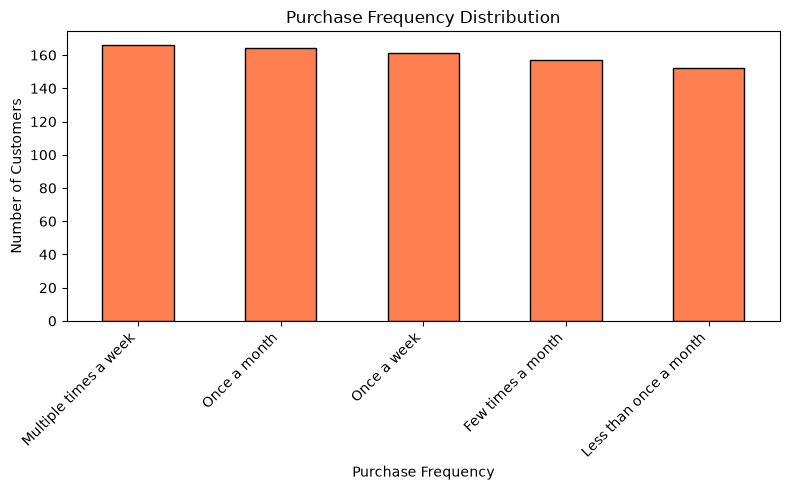

In [27]:
# Analysis of Purchase Frequency-

print("Purchase Frequency Distribution (counts):\n", df['Purchase_Frequency'].value_counts())
print("\nPercentage of Purchase Frequency Distribution:\n", df['Purchase_Frequency'].value_counts(normalize=True).round(3)*100)


plt.figure(figsize=(8,5))
df['Purchase_Frequency'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Purchase Frequency Distribution')
plt.xlabel('Purchase Frequency')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()  
plt.show()

Count of Individual Category:
 Purchase_Categories
Clothing and Fashion          476
Beauty and Personal Care      414
Home and Kitchen              405
Others                        396
Groceries and Gourmet Food    381
Name: count, dtype: int64


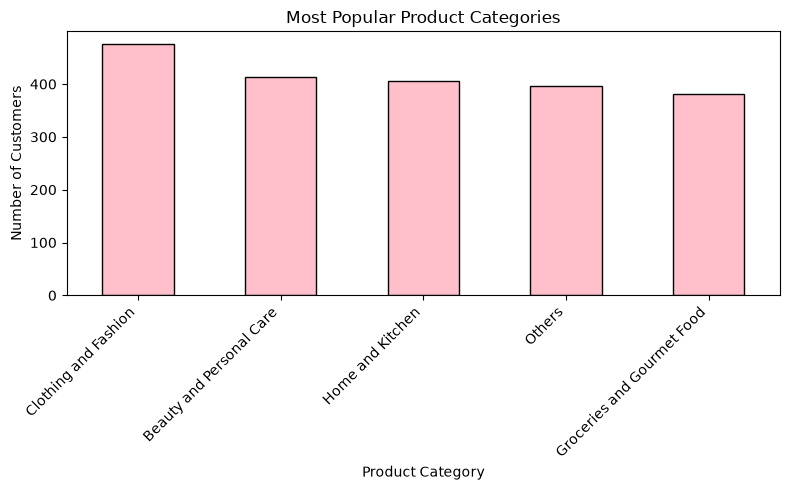

In [28]:
#Most Popular Product Category-
all_categories=df['Purchase_Categories'].str.split(';').explode()
print("Count of Individual Category:\n", all_categories.value_counts())


plt.figure(figsize=(8,5))
all_categories.value_counts().plot(kind='bar', color='pink', edgecolor='black')
plt.title('Most Popular Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Count of Product Search Method Distribution:
 Product_Search_Method
Others        182
Keyword       163
Categories    156
Filter        150
Unknown       149
Name: count, dtype: int64

% Product Search Method Distribution:
 Product_Search_Method
Others        22.8
Keyword       20.4
Categories    19.5
Filter        18.8
Unknown       18.6
Name: proportion, dtype: float64


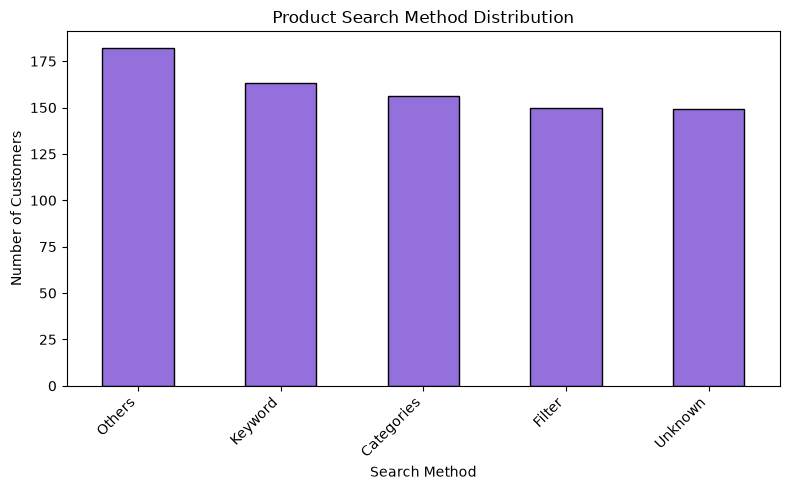

In [29]:
# Top Browsing Methods-
print("Count of Product Search Method Distribution:\n", df['Product_Search_Method'].value_counts())
print("\n% Product Search Method Distribution:\n", df['Product_Search_Method'].value_counts(normalize=True).round(3) * 100)


plt.figure(figsize=(8,5))
df['Product_Search_Method'].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Product Search Method Distribution')
plt.xlabel('Search Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cart Abandonment Factors (counts):
 Cart_Abandonment_Factors
Found a better price elsewhere                219
Others                                        196
High shipping costs                           194
Changed my mind or no longer need the item    191
Name: count, dtype: int64

Cart Abandonment Factors (%):
 Cart_Abandonment_Factors
Found a better price elsewhere                27.4
Others                                        24.5
High shipping costs                           24.2
Changed my mind or no longer need the item    23.9
Name: proportion, dtype: float64


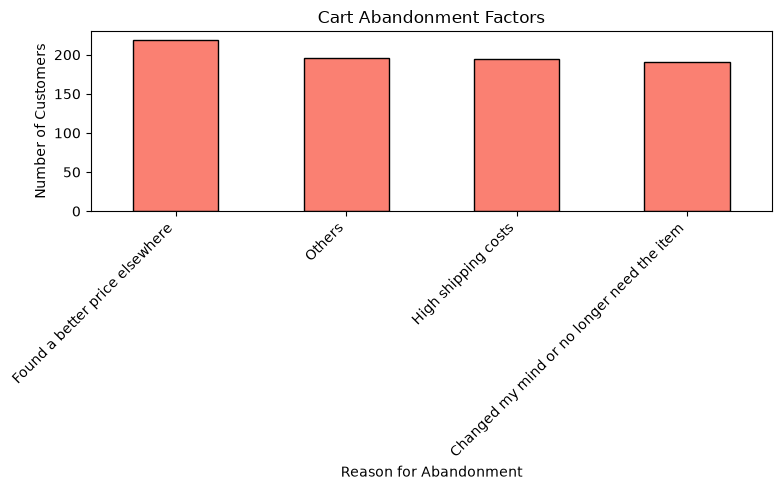

In [30]:
#Most common cart abandonment factors-
print("Cart Abandonment Factors (counts):\n", df['Cart_Abandonment_Factors'].value_counts())
print("\nCart Abandonment Factors (%):\n", df['Cart_Abandonment_Factors'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(8,5))
df['Cart_Abandonment_Factors'].value_counts().plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Cart Abandonment Factors')
plt.xlabel('Reason for Abandonment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [31]:
#Mean and Median of Shopping Satisfaction
print("Mean of Shopping Satisfaction:", df['Shopping_Satisfaction'].mean())
print("Median of Shopping Satisfaction:", df['Shopping_Satisfaction'].median())


Mean of Shopping Satisfaction: 2.98875
Median of Shopping Satisfaction: 3.0


In [32]:
# Recommendation Helpfulness
print("Distribution of Reccomendation Helpfulness:\n ", df['Recommendation_Helpfulness'].value_counts())
print("\n% Reccomendation Helpfulness:\n ", df['Recommendation_Helpfulness'].value_counts(normalize=True).round(3)*100)


Distribution of Reccomendation Helpfulness:
  Recommendation_Helpfulness
No           295
Yes          261
Sometimes    244
Name: count, dtype: int64

% Reccomendation Helpfulness:
  Recommendation_Helpfulness
No           36.9
Yes          32.6
Sometimes    30.5
Name: proportion, dtype: float64


In [36]:
df.columns.str.strip()
print(df.columns.tolist())

['Timestamp', 'age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Personalized_Recommendation_Frequency_Numeric', 'Recommendation_Helpfulness', 'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'transaction']


In [37]:
# Mean and Median of rating accuracy-
print("Mean of Rating_Accuracy:", df['Rating_Accuracy '].mean())
print("Median of Rating_Accuracy:", df['Rating_Accuracy '].median())

Mean of Rating_Accuracy: 2.96375
Median of Rating_Accuracy: 3.0


Summary statistics for all numeric columns:

              age  Customer_Reviews_Importance  Rating_Accuracy  \
count  800.000000                   800.000000        800.00000   
mean    36.053750                     2.988750          2.96375   
std     19.310087                     1.400384          1.42565   
min      3.000000                     1.000000          1.00000   
25%     18.000000                     2.000000          2.00000   
50%     37.000000                     3.000000          3.00000   
75%     53.000000                     4.000000          4.00000   
max     67.000000                     5.000000          5.00000   

       Shopping_Satisfaction  
count             800.000000  
mean                2.988750  
std                 1.407515  
min                 1.000000  
25%                 2.000000  
50%                 3.000000  
75%                 4.000000  
max                 5.000000  


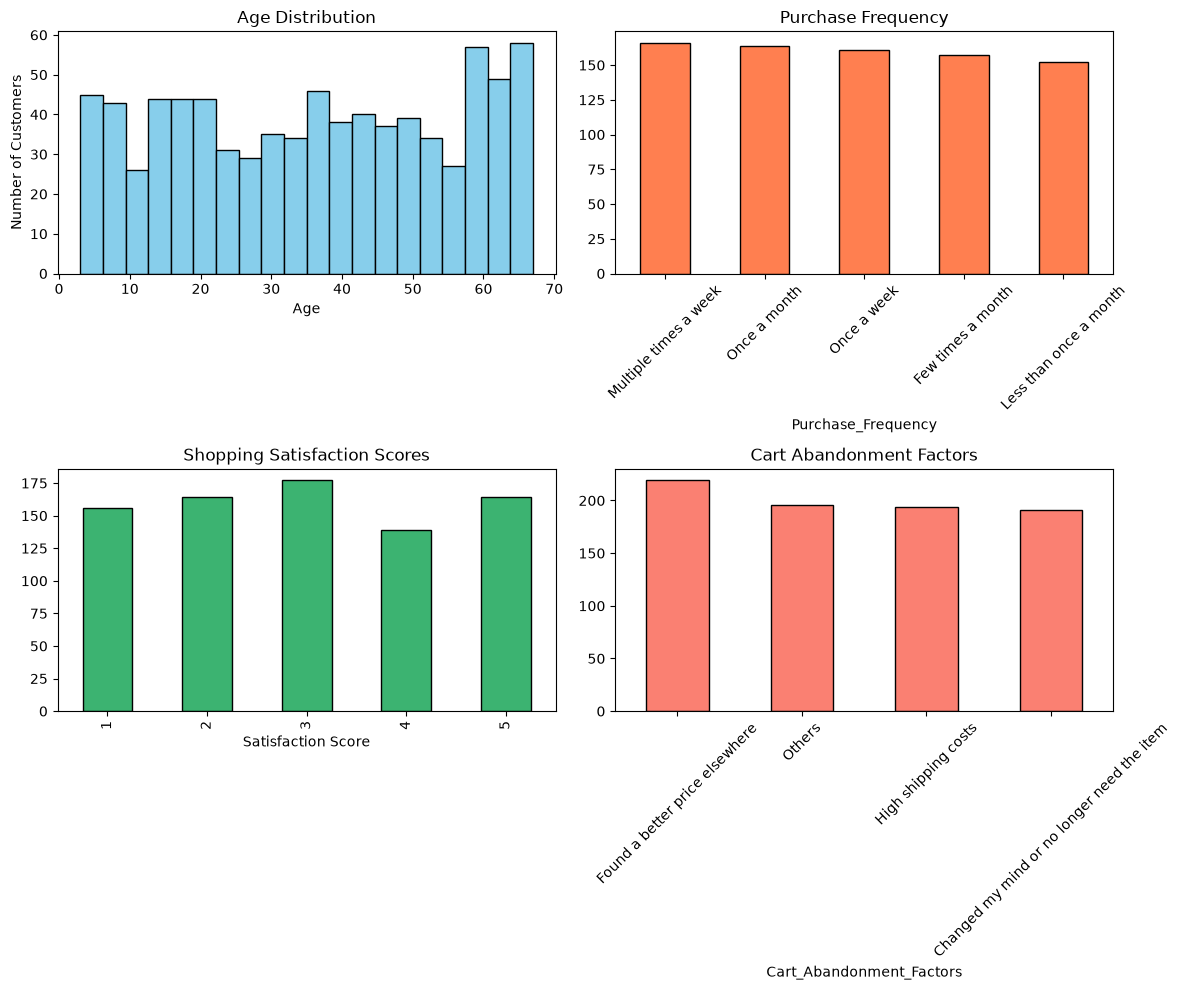

In [ ]:
#Summary statistics and visualizations for key behavioral variables-

print("Summary statistics for all numeric columns:\n")
print(df[['age', 'Customer_Reviews_Importance', 'Rating_Accuracy', 'Shopping_Satisfaction']].describe())


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#1:Age distribution
axes[0,0].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Number of Customers')

#2:Purchase Frequency
df['Purchase_Frequency'].value_counts().plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='black')
axes[0,1].set_title('Purchase Frequency')
axes[0,1].tick_params(axis='x', rotation=45)

#3:Shopping Satisfaction
df['Shopping_Satisfaction'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='mediumseagreen', edgecolor='black')
axes[1,0].set_title('Shopping Satisfaction Scores')
axes[1,0].set_xlabel('Satisfaction Score')

#4:Cart Abandonment Factors
df['Cart_Abandonment_Factors'].value_counts().plot(kind='bar', ax=axes[1,1], color='salmon', edgecolor='black')
axes[1,1].set_title('Cart Abandonment Factors')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()